# Credit Card Fraud Detection Analysis

**Module:** CMP7005 Programming for Data Analysis  
**Assessment:** PRAC1  
**Cardiff Met ID :** st20357375           
**ICBT ID:** CL/MCSDS/CMU/10/03

## Objective
This notebook presents the full workflow for analysing credit card transaction data and developing machine learning models to identify fraudulent transactions. The work includes dataset merging, exploratory data analysis, preprocessing, model development, evaluation, and improvement.

## Dataset Summary
The analysis is based on two CSV files provided for the assignment. The target variable is binary, where:
- `1` indicates a fraudulent transaction
- `0` indicates a non-fraudulent transaction

The dataset is highly imbalanced, so model evaluation will focus on more than accuracy alone.


# 1. Setup and Library Import
This section imports the libraries required for data handling, visualisation, preprocessing, and machine learning.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


# 2. Task 1: Data Handling and Merging
## 2.1 Load the datasets
The two CSV files were loaded into pandas DataFrames for inspection and merging.


In [2]:
data_path = Path("../data")

df1 = pd.read_csv(data_path / "Credit_Card_Dataset_2025_Sept_1.csv")
df2 = pd.read_csv(data_path / "Credit_Card_Dataset_2025_Sept_2.csv")

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)


Dataset 1 shape: (25134, 17)
Dataset 2 shape: (25134, 4)


## 2.2 Inspect dataset structure
Before merging, both datasets were examined to confirm the available columns, data types, and the shared key.


In [3]:
print("Dataset 1 columns:")
print(df1.columns.tolist())

print("\nDataset 2 columns:")
print(df2.columns.tolist())


Dataset 1 columns:
['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET']

Dataset 2 columns:
['INCOME', 'INCOME_TYPE', 'User', 'EDUCATION_TYPE']


In [4]:
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      25134 non-null  int64  
 1   ID              25134 non-null  int64  
 2   GENDER          25134 non-null  object 
 3   CAR             25134 non-null  object 
 4   REALITY         25134 non-null  object 
 5   NO_OF_CHILD     25134 non-null  int64  
 6   FAMILY_TYPE     25134 non-null  object 
 7   HOUSE_TYPE      25134 non-null  object 
 8   FLAG_MOBIL      25134 non-null  int64  
 9   WORK_PHONE      25134 non-null  int64  
 10  PHONE           25134 non-null  int64  
 11  E_MAIL          25134 non-null  int64  
 12  FAMILY SIZE     25133 non-null  float64
 13  BEGIN_MONTH     25134 non-null  int64  
 14  AGE             25134 non-null  int64  
 15  YEARS_EMPLOYED  25125 non-null  float64
 16  TARGET          25134 non-null  int64  
dtypes: float64(2), int64(10), objec

In [5]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INCOME          25134 non-null  float64
 1   INCOME_TYPE     25122 non-null  object 
 2   User            25134 non-null  int64  
 3   EDUCATION_TYPE  25134 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 785.6+ KB


## 2.3 Merge the datasets
The datasets were merged using the common primary key `ID`. An inner join was used so that only matching records from both files were retained in the final dataset.

The first dataset contains the primary key as `ID`, while the second dataset uses the column name `User` for the same identifier. To create a consistent key for merging, `User` was renamed to `ID`.

In [6]:
# Rename columns to standardise them across both datasets
df1.rename(columns={"TARGET": "Target"}, inplace=True)
df2.rename(columns={"User": "ID"}, inplace=True)

# Drop any accidental Unnamed index columns
df1 = df1.loc[:, ~df1.columns.str.contains("^Unnamed")]

# Merge the datasets
df = pd.merge(df1, df2, on="ID", how="inner")

print("Merged dataset shape:", df.shape)
df.head()


Merged dataset shape: (25134, 19)


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,Target,INCOME,INCOME_TYPE,EDUCATION_TYPE
0,5008806,M,Y,Y,0,Married,House / apartment,1,0,0,0,2.0,29,59,3.0,0,112500.0,Working,Secondary / secondary special
1,5008808,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
2,5008809,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
3,5008810,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
4,5008811,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special


## 2.3 Merge the datasets

In [7]:
print("Merged dataset shape:", df.shape)
print("Duplicate rows in merged dataset:", df.duplicated().sum())
print("Duplicate IDs in merged dataset:", df["ID"].duplicated().sum())

Merged dataset shape: (25134, 19)
Duplicate rows in merged dataset: 0
Duplicate IDs in merged dataset: 0


### Interpretation

The two datasets were successfully merged using the common primary key `ID`. Before merging, the `User` column in the second dataset was renamed to `ID` to standardise the identifier across both files. The unnecessary `Unnamed: 0` column was removed, and `TARGET` was renamed to `Target` for consistency. The final merged dataset contains 25,134 rows and 19 columns, forming the main dataset used for the remaining stages of the analysis.

# 3. Exploratory Data Analysis
## 3.1 Fundamental data understanding
This section examines the merged dataset to understand its structure, variable types, unique values, target balance, and missing values.


In [8]:
print("Number of rows and columns:", df.shape)
print("\nData types:")
display(df.dtypes)


Number of rows and columns: (25134, 19)

Data types:


ID                  int64
GENDER             object
CAR                object
REALITY            object
NO_OF_CHILD         int64
FAMILY_TYPE        object
HOUSE_TYPE         object
FLAG_MOBIL          int64
WORK_PHONE          int64
PHONE               int64
E_MAIL              int64
FAMILY SIZE       float64
BEGIN_MONTH         int64
AGE                 int64
YEARS_EMPLOYED    float64
Target              int64
INCOME            float64
INCOME_TYPE        object
EDUCATION_TYPE     object
dtype: object

In [9]:
summary_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isnull().sum().values,
    "unique_values": df.nunique(dropna=False).values
})

summary_df


,column,dtype,missing_values,unique_values
0,ID,int64,0,25134
1,GENDER,object,0,2
2,CAR,object,0,2
3,REALITY,object,0,2
4,NO_OF_CHILD,int64,0,9
5,FAMILY_TYPE,object,0,5
6,HOUSE_TYPE,object,0,6
7,FLAG_MOBIL,int64,0,1
8,WORK_PHONE,int64,0,2
9,PHONE,int64,0,2


In [10]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,25134.0,5.078838e+06,41941.018788,5008806.0,5042228.25,5079004.0,5115603.75,5150487.0
NO_OF_CHILD,25134.0,5.123339e-01,0.787785,0.0,0.00,0.0,1.00,19.0
FLAG_MOBIL,25134.0,1.000000e+00,0.000000,1.0,1.00,1.0,1.00,1.0
WORK_PHONE,25134.0,2.738124e-01,0.445923,0.0,0.00,0.0,1.00,1.0
PHONE,25134.0,2.927906e-01,0.455052,0.0,0.00,0.0,1.00,1.0
E_MAIL,25134.0,1.006605e-01,0.300885,0.0,0.00,0.0,0.00,1.0
FAMILY SIZE,25133.0,2.294076e+00,0.947607,1.0,2.00,2.0,3.00,20.0
BEGIN_MONTH,25134.0,2.612059e+01,16.439658,0.0,12.00,24.0,39.00,60.0
AGE,25134.0,4.059000e+01,10.348136,21.0,33.00,40.0,48.00,450.0
YEARS_EMPLOYED,25125.0,7.205214e+00,6.415004,0.0,3.00,5.0,10.00,43.0


### Interpretation

The descriptive statistics show that several numerical variables have wide ranges. `INCOME` is strongly right-skewed, indicating that most records fall within lower or middle income bands while a smaller number of records have very high income values. `YEARS_EMPLOYED` also shows variation across customers.

One unusual observation is that the maximum value recorded for `AGE` is 450, which is not realistic and suggests the presence of at least one abnormal or incorrectly entered value. In addition, `NO_OF_CHILD` and `FAMILY SIZE` contain some extreme values. These observations were reviewed during outlier inspection rather than removed automatically, because not all extreme values in financial datasets are necessarily invalid.


## 3.2 Missing value analysis
Missing values were checked across all columns to determine which variables require imputation during preprocessing.


In [11]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
missing_values


INCOME_TYPE       12
YEARS_EMPLOYED     9
FAMILY SIZE        1
dtype: int64

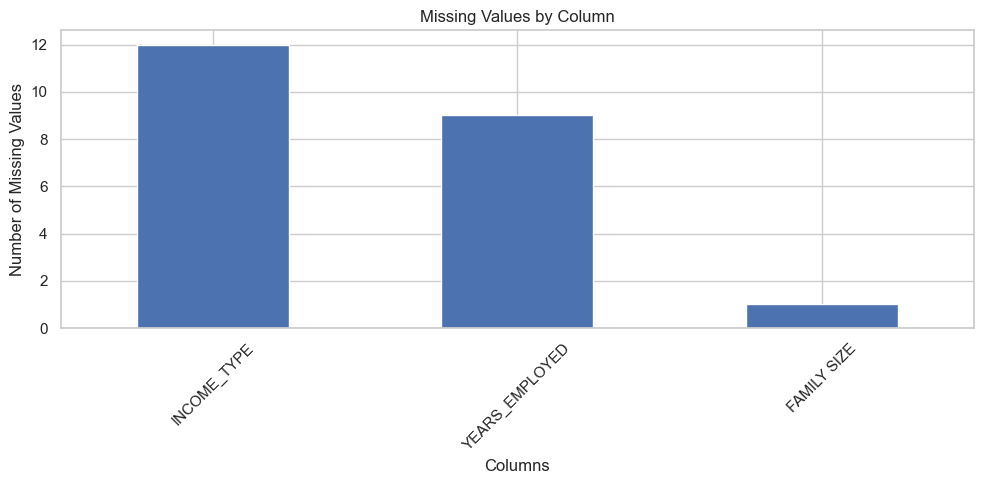

In [12]:
plt.figure(figsize=(10, 5))
missing_values.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../screenshots/task2_missing_values.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation
The chart shows that missing values are present in selected variables in small quantities (INCOME_TYPE, YEARS_EMPLOYED, FAMILY SIZE). Because the proportion of missing data is tiny, using median and most frequent imputation is a sensible and robust approach.


## 3.3 Target variable distribution
The target variable was analysed to understand the class balance between fraudulent and non-fraudulent transactions.


In [ ]:
target_counts = df["Target"].value_counts()
target_percent = df["Target"].value_counts(normalize=True) * 100

print(target_counts)
print("\nPercentage distribution:")
print(target_percent.round(2))


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Target")
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.savefig("../screenshots/task2_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation
The class distribution confirms a severe imbalance, with only 1.68% fraudulent cases. This justifies the use of recall and F1-score as priority metrics during model evaluation. A model can achieve high accuracy by predicting most cases as non-fraud, since almost all transactions are legitimate. Therefore, accuracy alone is misleading; recall matters because missing fraud is costly, and precision matters because too many false alarms are also a problem.


## 3.4 Data preprocessing
This section prepares the dataset for modelling by checking duplicates, separating features and target, identifying variable types, separating informative from non-informative features, and reviewing categories.


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


In [ ]:
# Remove non-informative columns
# FLAG_MOBIL has only one unique value and adds no predictive information.
df = df.drop(columns=["FLAG_MOBIL"])

# Separate features and target
# ID is removed because it is only an identifier and has no predictive meaning.
X = df.drop(columns=["Target", "ID"])
y = df["Target"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


In [ ]:
for col in ['INCOME_TYPE', 'EDUCATION_TYPE', 'FAMILY_TYPE']:
    print(f"\nValue Counts for {col}:")
    print(X[col].value_counts(normalize=True).round(3))


### Interpretation
FLAG_MOBIL was removed because it contained only one unique value and therefore had no predictive value. ID was also excluded because the model could learn meaningless patterns based on record numbering rather than actual fraud behavior. The categorical value counts provide a profile of our customer base, with the majority being Working income types and Secondary level educated.


## 3.5 Outlier inspection

Selected continuous numerical variables were examined using boxplots to identify potential extreme values. In fraud detection data, unusual values may either reflect genuine rare behaviour or possible data-quality issues, so they were reviewed carefully rather than removed automatically.


In [ ]:
outlier_cols = ["INCOME", "AGE", "YEARS_EMPLOYED", "FAMILY SIZE", "BEGIN_MONTH"]

for col in outlier_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


### Interpretation

The boxplots confirm that `INCOME` contains several high-value outliers, which is expected in financial data and does not automatically indicate an error. However, the `AGE` variable includes at least one clearly unrealistic value, which suggests that the dataset may contain a limited number of abnormal entries. Since the assignment focuses on practical fraud detection rather than aggressive data removal, the extreme values were retained but acknowledged as a limitation of the dataset.


## 3.6 Univariate analysis
Univariate analysis was conducted to understand the distribution of meaningful individual variables.


In [ ]:
univariate_num = ["AGE", "INCOME", "YEARS_EMPLOYED", "FAMILY SIZE", "BEGIN_MONTH"]

for col in univariate_num:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    if col == "INCOME":
        plt.savefig("../screenshots/task2_income_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
univariate_cat = ["GENDER", "INCOME_TYPE", "EDUCATION_TYPE", "FAMILY_TYPE", "HOUSE_TYPE"]

for col in univariate_cat:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Interpretation
The histograms confirm that some numerical variables, such as INCOME, are significantly skewed. The count plots highlight the dominant customer demographics, confirming that `Secondary / secondary special` is the most common education level and most individuals have a `House / apartment` living condition.


## 3.7 Bivariate analysis
Bivariate analysis was used to examine the relationship between selected features and the target variable to see how fraud varies across features.


In [ ]:
bivariate_cat = ["INCOME_TYPE", "EDUCATION_TYPE", "FAMILY_TYPE", "CAR", "REALITY"]

for col in bivariate_cat:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue="Target")
    plt.title(f"{col} by Target")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
bivariate_num = ["INCOME", "AGE", "YEARS_EMPLOYED", "BEGIN_MONTH"]

for col in bivariate_num:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Target", y=col)
    plt.title(f"{col} by Target")
    plt.tight_layout()
    plt.show()


In [ ]:
df.groupby("Target")[["INCOME", "AGE", "YEARS_EMPLOYED", "FAMILY SIZE"]].mean()


### Interpretation

The grouped summary shows some noticeable differences between fraudulent and non-fraudulent cases. Fraudulent cases have a slightly higher average income, a slightly lower average age, and fewer average years of employment than non-fraudulent cases. The difference in family size is small. These patterns do not prove causation, but they suggest that employment duration and income may contribute useful information during model building.


## 3.8 Multivariate analysis
A correlation matrix was created for numerical variables to identify linear relationships and potential redundancy among features.


In [ ]:
corr = df[numerical_cols + ["Target"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../screenshots/task2_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

The correlation heatmap shows that no single numerical feature has a strong linear relationship with the target variable. This suggests that fraud detection in this dataset is unlikely to depend on one dominant predictor alone. Instead, the target may be influenced by a combination of variables, which supports the use of machine learning models that can learn more complex decision patterns.


# 4. Model Building
## 4.1 Train test split
The dataset was split into training and test sets using stratification to preserve the original class distribution.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


## 4.2 Preprocessing pipeline
Separate preprocessing steps were applied to numerical and categorical features. Numerical variables were imputed with the median, while categorical variables were imputed with the most frequent value and then one-hot encoded.


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])


## 4.3 Model 1: Logistic Regression
Logistic Regression was used as a baseline model because it is interpretable, efficient, and commonly applied to binary classification problems.


In [ ]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)


In [ ]:
lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr)
}

pd.DataFrame(lr_results, index=["Logistic Regression"]).round(4)


In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../screenshots/task3_logistic_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation
This model is too aggressive. It catches many fraud cases (with a high recall), but it flags far too many legitimate transactions as fraudulent. Precision is extremely poor, meaning it relies heavily on predicting fraud broadly, generating too many false alarms. This is useful if the goal is "catch as many frauds as possible", but it creates too many false positives as seen in the confusion matrix.


## 4.4 Model 2: Random Forest
Random Forest was selected as the second model because it can capture non-linear patterns and interactions between variables more effectively than a linear baseline model.


In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)


In [ ]:
rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
}

pd.DataFrame(rf_results, index=["Random Forest"]).round(4)


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../screenshots/task3_random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation
This model is conservative. Accuracy is high, and precision is much better than Logistic Regression. When it predicts fraud, it is more likely to be correct. However, recall is poor, meaning it misses most fraudulent transactions.


## 4.5 Model comparison
The two models were compared using accuracy, precision, recall, and F1-score. In an imbalanced fraud detection problem, recall is especially important because failing to identify fraudulent cases can be costly.


In [ ]:
comparison_df = pd.DataFrame([lr_results, rf_results], index=["Logistic Regression", "Random Forest"])
comparison_df.round(4)


### Interpretation

The results show a clear trade-off between the models. Logistic Regression achieved much higher recall, meaning it identified more fraudulent cases, but its precision was extremely low and it produced many false positives. Random Forest achieved much higher accuracy and precision, but it detected only a small proportion of fraud cases.

This conflict occurs because the dataset is highly imbalanced. A model can achieve strong overall accuracy by predicting most transactions as non-fraudulent, while still performing poorly on the minority fraud class. For this reason, recall and F1-score provide more meaningful insight than accuracy alone.


## 4.6 Model improvement using SMOTE
To improve fraud detection performance, SMOTE was applied to the training data after preprocessing. This helps reduce the impact of class imbalance by synthetically increasing the minority class in the training set.


In [ ]:
# Fit preprocessing on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("Original training shape:", X_train_processed.shape, y_train.shape)
print("After SMOTE:", X_train_smote.shape, y_train_smote.shape)


In [ ]:
rf_improved = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_improved.fit(X_train_smote, y_train_smote)
y_pred_rf_improved = rf_improved.predict(X_test_processed)


In [ ]:
rf_improved_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf_improved),
    "Precision": precision_score(y_test, y_pred_rf_improved),
    "Recall": recall_score(y_test, y_pred_rf_improved),
    "F1 Score": f1_score(y_test, y_pred_rf_improved)
}

pd.DataFrame(rf_improved_results, index=["Improved Random Forest"]).round(4)


In [ ]:
final_comparison = pd.DataFrame(
    [lr_results, rf_results, rf_improved_results],
    index=["Logistic Regression", "Random Forest", "Improved Random Forest"]
)

final_comparison.round(4)


In [ ]:
comparison_plot = final_comparison[["Precision", "Recall", "F1 Score"]]
comparison_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../screenshots/task3_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Final model selection

Among the evaluated models, the Improved Random Forest was selected as the final model for deployment. Although its overall accuracy was slightly lower than the baseline Random Forest, it achieved better recall and the highest F1-score among the tested Random Forest models. This makes it a more suitable choice for identifying fraudulent transactions in a highly imbalanced dataset.


## 4.7 Saving and loading trained models

The trained models were saved using `joblib` so they could be reused in the application without retraining. The baseline Logistic Regression and Random Forest models were saved as complete pipelines because they include preprocessing within the pipeline itself.

The improved Random Forest model was trained on transformed data after resampling, so it was saved separately from the fitted preprocessor. This allows the same preprocessing steps to be applied to new user inputs before prediction in the FastAPI application.


In [ ]:
model_dir = Path("../app/models")
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(lr_pipeline, model_dir / "model_logistic.pkl")
joblib.dump(rf_pipeline, model_dir / "model_random_forest.pkl")
joblib.dump(preprocessor, model_dir / "preprocessor.pkl")
joblib.dump(rf_improved, model_dir / "model_random_forest_smote.pkl")

print("All model files saved successfully.")


## 4.8 Testing loaded models on known fraud cases

To confirm that the saved deployment model works correctly on minority-class examples, a small sample of actual fraud cases from the test set was selected and passed through the loaded preprocessor and model.


In [ ]:
loaded_lr = joblib.load(model_dir / "model_logistic.pkl")
loaded_rf = joblib.load(model_dir / "model_random_forest.pkl")
loaded_preprocessor = joblib.load(model_dir / "preprocessor.pkl")
loaded_rf_smote = joblib.load(model_dir / "model_random_forest_smote.pkl")

print("All model files loaded successfully.")

fraud_sample = X_test[y_test == 1].iloc[:5].copy()
fraud_actual = y_test[y_test == 1].iloc[:5].values

fraud_sample_processed = loaded_preprocessor.transform(fraud_sample)
fraud_sample_pred = loaded_rf_smote.predict(fraud_sample_processed)

fraud_results = fraud_sample.copy()
fraud_results["Actual_Target"] = fraud_actual
fraud_results["Improved_RF_Prediction"] = fraud_sample_pred

fraud_results


### Interpretation

This test confirms that the saved model and preprocessor can be loaded successfully and used to generate predictions on unseen records. Using actual fraud cases in the demonstration provides a more meaningful validation of the deployment workflow than testing only non-fraudulent examples.


# 5. Conclusion
This notebook presented a complete workflow for credit card fraud detection using data analysis and machine learning. 

We refined our data by removing non-predictive variables `ID` and `FLAG_MOBIL`. The datasets were examined, cleaned, and analysed using insightful bivariate and grouped summaries. After addressing feature imbalances, two initial classification models were trained. Recognizing the trade-offs of Logistic Regression (too aggressive) against a standard Random Forest (too conservative), SMOTE was introduced. 

Among the tested models, the *Improved Random Forest* was selected as the preferred candidate because it provided the best balance between recall and precision, resulting in the highest F1-score while retaining strong overall accuracy.

The final selected model was saved and reloaded successfully, which supports its use in the application development stage of the assignment.

Finally, preprocessing pipelines and candidate models were saved appropriately, demonstrating professional model persistence for integration into deployment environments like FastAPI.
